# Piecewise-Linear Transformation

In [25]:
import cv2 as cv 
import numpy as np
import matplotlib.pyplot as plt
import sys

In [26]:
img=cv.imread('img/pollen.tif')
img=cv.resize(img,dsize=(0,0),fx=0.25,fy=0.25)


In [27]:
def contrast_stretching(img, r1, s1, r2, s2):
    lut = np.zeros(256, dtype=np.uint8)
    
    for r in range(256):
        if 0 <= r <= r1:
            lut[r] = (s1 / r1) * r
        elif r1 < r <= r2:
            lut[r] = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1
        else:
            lut[r] = ((255 - s2) / (255 - r2)) * (r - r2) + s2
            
    return cv.LUT(img, lut)



In [28]:
res_stretch = contrast_stretching(img, 140, 0, 170, 255)

ret, res_thresh = cv.threshold(img, 127, 255, cv.THRESH_BINARY)

r1, s1 = 90, 10
r2, s2 = 160, 245

# r1, s1 = 150, 0
# r2, s2 = 200, 255
          
# r1, s1 = 10, 0
# r2, s2 = 50, 255

# r1, s1 = 200, 0
# r2, s2 = 255, 255

# r1, s1 = 120, 0
# r2, s2 = 125, 255


res_c = contrast_stretching(img, r1, s1, r2, s2)

# res_d = cv.threshold(img, 128, 255, cv.THRESH_BINARY)[1]  너무 어두움
# res_d = cv.threshold(img, 110, 255, cv.THRESH_BINARY)[1]   
res_d = cv.threshold(img, 111, 255, cv.THRESH_BINARY)[1]   

combined = np.hstack((img, res_c, res_d))
cv.imshow("combined", combined)
cv.waitKey(0)
cv.destroyAllWindows()

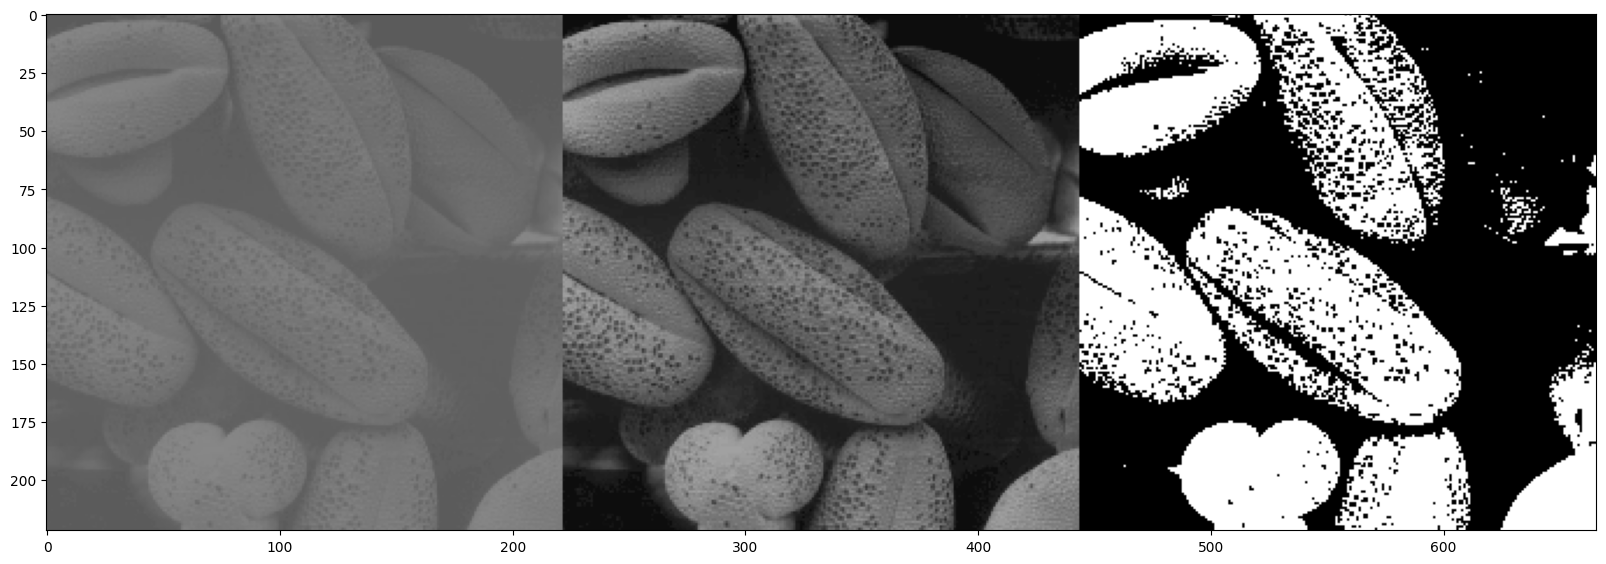

In [29]:
plt.figure(figsize=(20, 10)) 
plt.imshow(cv.cvtColor(combined , cv.COLOR_BGR2RGB))
plt.show() 

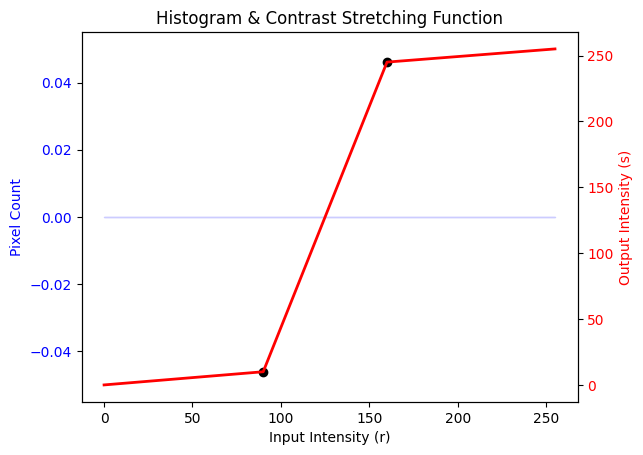

In [30]:
def visualize_transformation(img, r1, s1, r2, s2):
    # 1. 히스토그램 계산
    hist = cv.calcHist([img], [0], None, [256], [0, 256])

    x = np.arange(256)
    y = np.zeros(256)
    for i in range(256):
        if i <= r1: y[i] = (s1/r1)*i
        elif i <= r2: y[i] = ((s2-s1)/(r2-r1))*(i-r1) + s1
        else: y[i] = ((255-s2)/(255-r2))*(i-r2) + s2

    # 3. 그래프 그리기
    fig, ax1 = plt.subplots()

    # 왼쪽 축: 히스토그램 (픽셀 빈도)
    ax1.set_xlabel('Input Intensity (r)')
    ax1.set_ylabel('Pixel Count', color='blue')
    ax1.fill_between(x, hist.flatten(), color='blue', alpha=0.2, label='Histogram')
    ax1.tick_params(axis='y', labelcolor='blue')

    # 오른쪽 축: 변환 함수 (Output s)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Output Intensity (s)', color='red')
    ax2.plot(x, y, color='red', linewidth=2, label='Trans Function')
    ax2.scatter([r1, r2], [s1, s2], color='black') # 변곡점 표시
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title('Histogram & Contrast Stretching Function')
    plt.show()


img = cv.imread('pollen.tif', cv.IMREAD_GRAYSCALE)
visualize_transformation(img, 90, 10, 160, 245)

Fig3.10(a) 영상에 대해 오른쪽과 같은 결과가 나오도록 여러가지 경우에 대해 실험하고,  
결과를 분석해보세요.

Piecewise-Linear Transformation은   
지정한 두 좌표 값을 기준으로 두고 (범위 제한)
threshold로 어느정도로 빛을 통과 시킬지 말지를 정한다

r1, s1 = 90, 10
r2, s2 = 160, 245 

에 범위가 가장 적절한 지점이었다. 


| 상황          | 원본 데이터 분포 (r1∼r2) | 문제점    | 해결 전략              |
| ----------- | ----------------- | ------ | ------------------ |
| A: 안개/뿌연 영상 | 중간~밝은 쪽 (150∼200) | 대비 부족  | 구간을 0∼255로 확장      |
| B: 야간 촬영    | 어두운 쪽 (10∼50)     | 너무 어두움 | r2를 낮게 잡아 밝게 끌어올림  |
| C: 과다 노출    | 아주 밝은 쪽 (200∼255) | 하얗게 날림 | s1을 낮춰 어두운 톤 강제 부여 |
| D: 정밀 분석    | 초미세 구간 (120∼125)  | 식별 불가  | 해당 구간만 극단적으로 팽창    |
| E: 일반/표준    | 전체 (0∼255)        | 문제 없음  | 변환 불필요 (기울기 1)     |


실제로 다른 경우에서는 어떤 범위를 잡아야 하는지 궁금해서 제미니에게 물어 본 예시들


C:\Users\ynham\AppData\Local\Temp\ipykernel_32872\2474805238.py:63: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(res.ravel(), 256, [0, 256], color='blue', alpha=0.6)


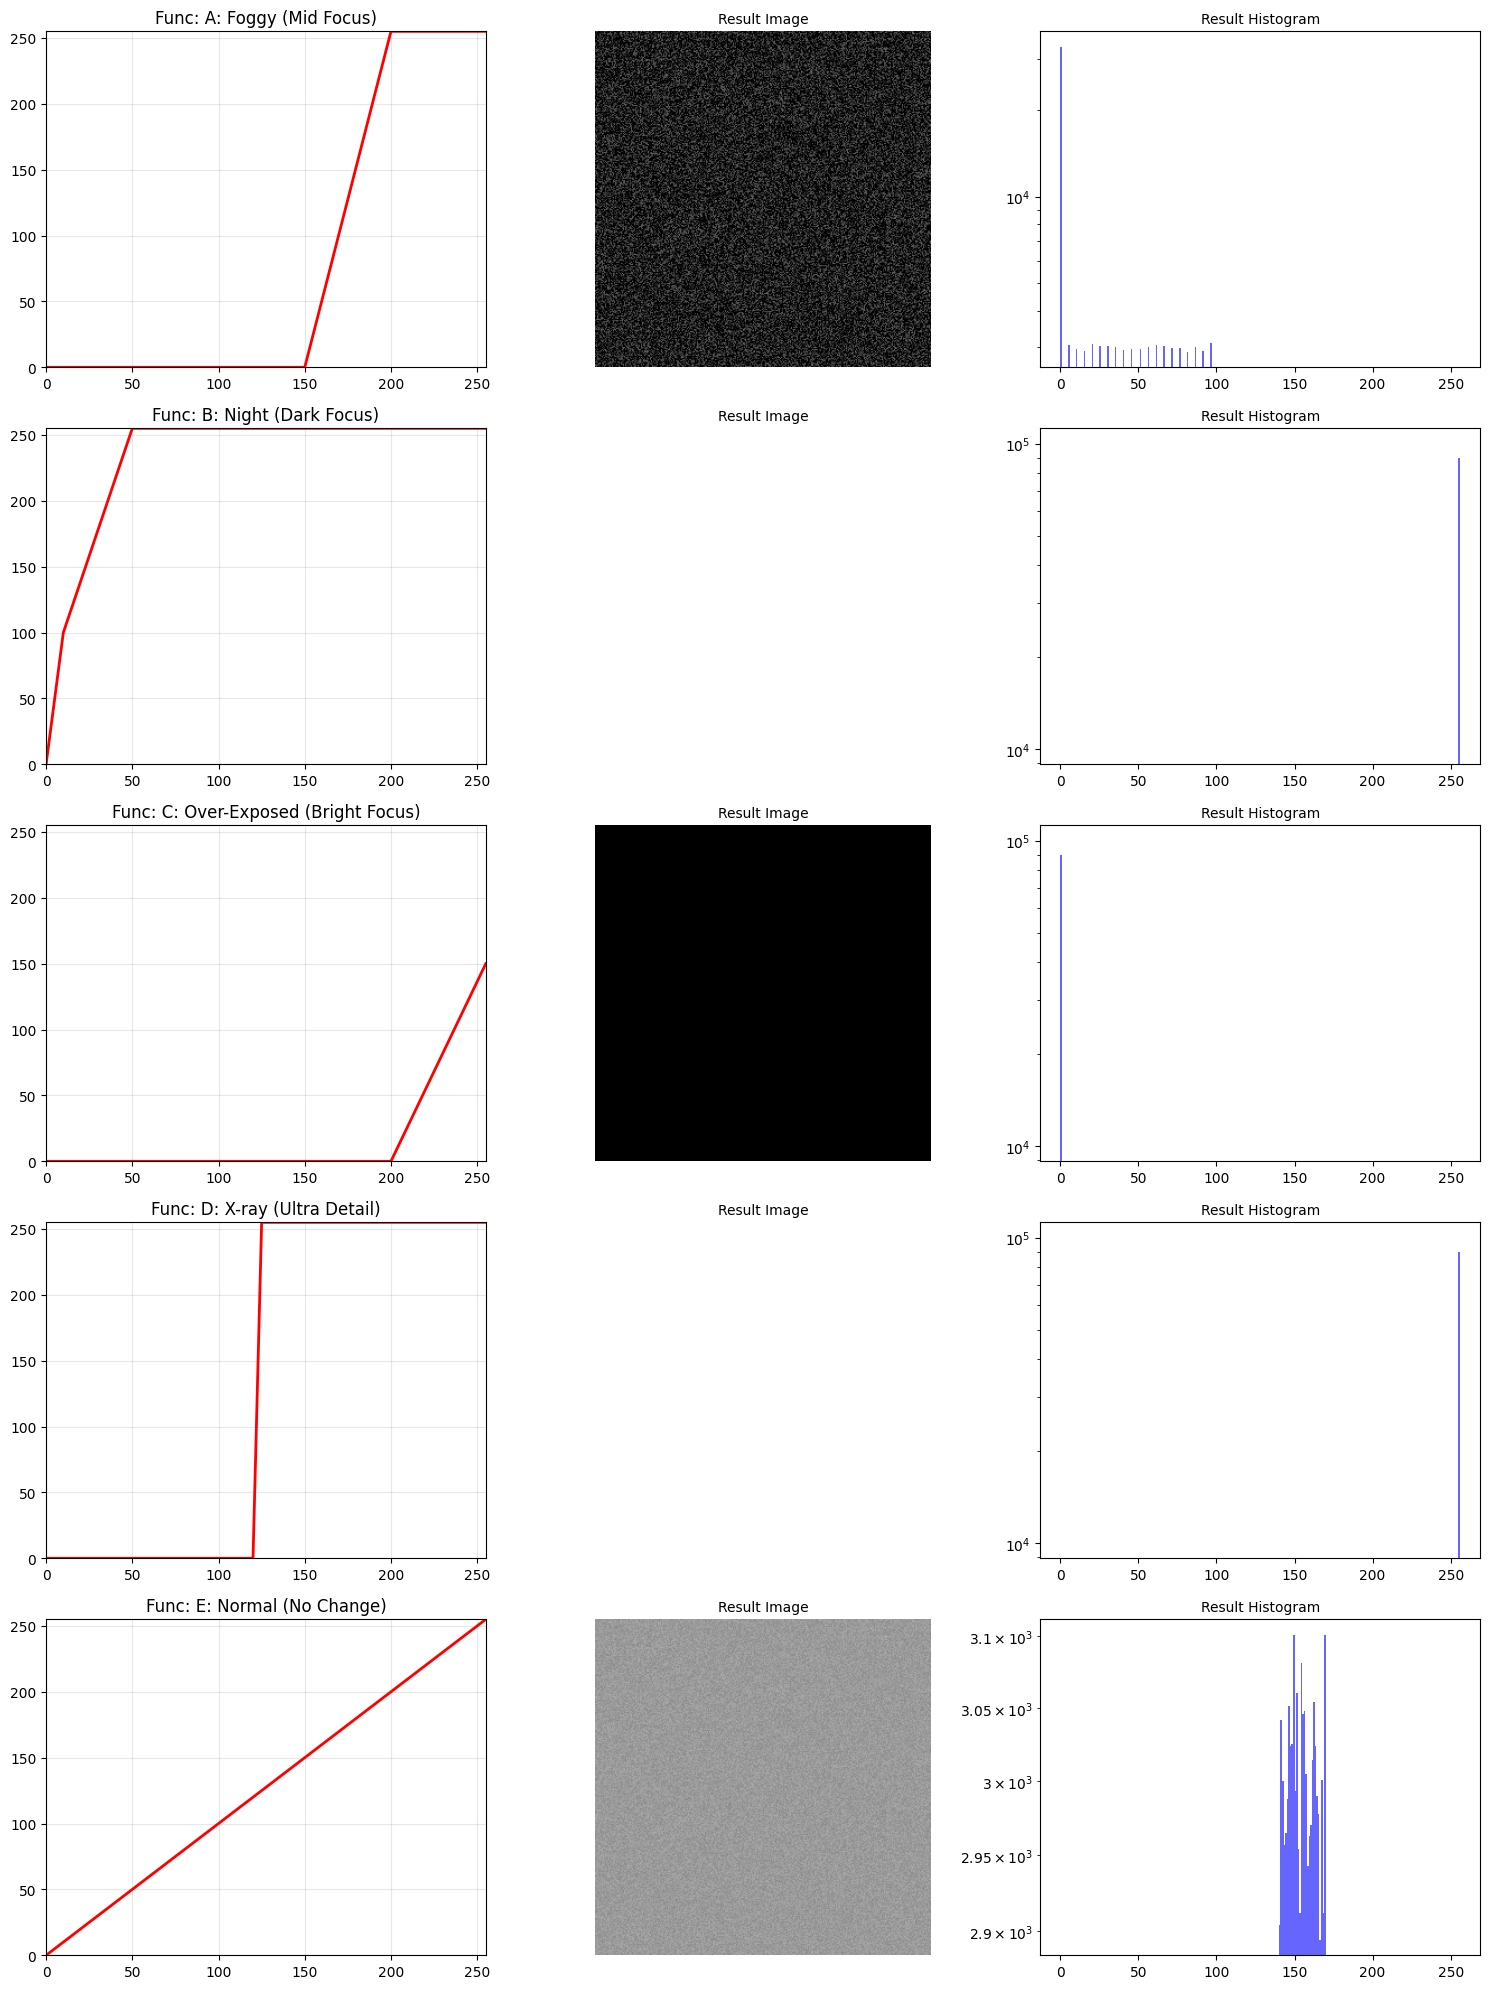

In [31]:

def contrast_stretching(img, r1, s1, r2, s2):
    # 0으로 나누기 방지를 위한 룩업 테이블 생성
    lut = np.zeros(256, dtype=np.uint8)
    for r in range(256):
        if r <= r1:
            # r1이 0일 경우 바로 s1 대입, 아니면 기울기 계산
            lut[r] = s1 if r1 == 0 else (s1 / r1) * r
        elif r <= r2:
            # r1과 r2가 같을 경우(이진화) s2 대입, 아니면 중간 기울기 계산
            lut[r] = s2 if r1 == r2 else ((s2 - s1) / (r2 - r1)) * (r - r1) + s1
        else:
            # r2가 255일 경우 s2 대입, 아니면 마지막 구간 기울기 계산
            lut[r] = s2 if r2 == 255 else ((255 - s2) / (255 - r2)) * (r - r2) + s2
            
    # 값의 범위를 0~255로 제한 (Clip) 후 타입 변환
    return cv.LUT(img, np.clip(lut, 0, 255).astype(np.uint8))

# 1. 이미지 로드
img = cv.imread('pollen.tif', cv.IMREAD_GRAYSCALE)
if img is None:
    # 이미지가 없을 경우를 대비한 가상 데이터 (회색 배경)
    img = np.random.randint(140, 170, (300, 300), dtype=np.uint8)

# 2. 5가지 실험 상황 설정
scenarios = [
    (150, 0, 200, 255, "A: Foggy (Mid Focus)"),
    (10, 100, 50, 255, "B: Night (Dark Focus)"),
    (200, 0, 255, 150, "C: Over-Exposed (Bright Focus)"),
    (120, 0, 125, 255, "D: X-ray (Ultra Detail)"),
    (0, 0, 255, 255, "E: Normal (No Change)") # r1=0인 케이스
]

plt.figure(figsize=(15, 20))

for i, (r1, s1, r2, s2, title) in enumerate(scenarios):
    # 영상 처리 적용
    res = contrast_stretching(img, r1, s1, r2, s2)
    
    # [열 1] 변환 함수 그래프 (빨간 선)
    plt.subplot(5, 3, i*3 + 1)
    x = np.arange(256)
    # 그래프 시각화를 위한 안전한 계산 (ZeroDivision 방지)
    y = []
    for v in x:
        if v <= r1: val = s1 if r1 == 0 else (s1/r1)*v
        elif v <= r2: val = s2 if r1 == r2 else ((s2-s1)/(r2-r1))*(v-r1)+s1
        else: val = s2 if r2 == 255 else ((255-s2)/(255-r2))*(v-r2)+s2
        y.append(val)
    
    plt.plot(x, y, 'r', linewidth=2)
    plt.title(f"Func: {title}", fontsize=12)
    plt.xlim(0, 255); plt.ylim(0, 255)
    plt.grid(True, alpha=0.3)

    # [열 2] 결과 영상
    plt.subplot(5, 3, i*3 + 2)
    plt.imshow(res, cmap='gray', vmin=0, vmax=255)
    plt.title("Result Image", fontsize=10)
    plt.axis('off')

    # [열 3] 결과 히스토그램
    plt.subplot(5, 3, i*3 + 3)
    plt.hist(res.ravel(), 256, [0, 256], color='blue', alpha=0.6)
    plt.title("Result Histogram", fontsize=10)
    plt.yscale('log') # 빈도가 낮은 구간도 보기 위해 로그 스케일

plt.tight_layout()
plt.show()

res_stretch = contrast_stretching(img, 70, 30, 180, 220)  
ret, res_thresh = cv.threshold(img, 127, 255, cv.THRESH_BINARY)  

r1, s1 = 90, 10    
r2, s2 = 160, 245    
에 비해서 아무것도 안보이는 것도 생각해보면 당연한 결과이다   
범위가 적절하게 특정되지 않았기 때문이다.   

E의 경우 데이터의 위치를 잘 보여준다.  

